## Notebook to construct the test plant outage schedule

In [120]:
import sys
sys.path.insert(0, '../../../src/CPM/')
from PertMain2 import Pert, Activity
import random
from datetime import datetime, time
import networkx as nx
import matplotlib.pyplot as plt

random.seed(0)

In [121]:
# Main outage blocks
baseSchedule   = {'start': ['1','2','3'], 
                  '1': ['4','5','6','10'], 
                  '2': ['15','16'], 
                  '3': ['100','101','102','107','108'], 
                  '4': ['7'],
                  '5': ['7'],  
                  '6': ['8','9'],
                  '7': ['8'], 
                  '8': ['301'],
                  '9': ['301'],  

                  '10': ['11','12'], 
                  '11': ['13','14'],
                  '12': ['13','14'], 
                  '13': ['302'], 
                  '14': ['302'],
                  '15': ['17'],  
                  '16': ['17'],
                  '17': ['18','19','20'], 
                  '18': ['21','22'],
                  '19': ['21','22'],  
                  '20': ['21','22'], 
                  '21': ['302'],
                  '22': ['302'],

                  '100': ['103'], 
                  '101': ['103'], 
                  '102': ['105','106'], 
                  '103': ['104','105'], 
                  '104': ['109'],
                  '105': ['109'],  
                  '106': ['109'],
                  '107': ['110'], 
                  '108': ['110'],
                  '109': ['303'], 
                  '110': ['303'],  

                  '301': ['end'], 
                  '302': ['end'], 
                  '303': ['end'],                   

                  'end':[]}

Nmin = 1
Nmax = 3
numAct = {}
for act in baseSchedule.keys():
    if act in ['start','end']:
        numAct[act] = 1
    else:
        numAct[act] = random.randint(Nmin, Nmax)

fullActDict = {}
for act in baseSchedule.keys():
    if act not in ['start','end']:
        for i in range(numAct[act]):
            name = act +'-'+ str(i)
            duration = random.random()*10.0
            fullActDict[name] = Activity(name, duration)
            print(str(name) + ' = Activity("'+str(name)+'",'+str(duration)+', res={"res1":1})')
    elif act=='start':
        fullActDict['start'] = Activity('start', 1.)
        print('start = Activity("start",'+str(duration)+', res={"res1":1})')
    elif act=='end':
        fullActDict['end'] = Activity('end', 1.)
        print('end = Activity("end",'+str(duration)+', res={"res1":1})')
    else:
        print('error1') 

outageSchedule = {}
for act in baseSchedule.keys():
    if act=='end':
        outageSchedule[fullActDict['end']] = []
    else:
        for i in range(numAct[act]):
            if act=='start':
                name = 'start'
            else:
                name = act +'-'+ str(i)
                
            if i==numAct[act]-1:
                outageSchedule[fullActDict[name]] = []
                for desc in baseSchedule[act]:
                    if desc=='end':
                        succ = 'end'
                    else:
                        succ = desc +'-'+ str(0)
                    outageSchedule[fullActDict[name]].append(fullActDict[succ])
            else:
                succ = act +'-'+ str(i+1)
                outageSchedule[fullActDict[name]] = [fullActDict[succ]]

len(fullActDict.keys())

start = Activity("start",3.352704781672178, res={"res1":1})
1-0 = Activity("1-0",6.4042340154209025, res={"res1":1})
1-1 = Activity("1-1",2.0447774951611732, res={"res1":1})
2-0 = Activity("2-0",5.5252367613471876, res={"res1":1})
2-1 = Activity("2-1",4.426933591463412, res={"res1":1})
3-0 = Activity("3-0",5.2135363415250415, res={"res1":1})
4-0 = Activity("4-0",0.6227958802154521, res={"res1":1})
4-1 = Activity("4-1",9.18464895700658, res={"res1":1})
5-0 = Activity("5-0",9.159944803568846, res={"res1":1})
5-1 = Activity("5-1",0.9327186435241008, res={"res1":1})
5-2 = Activity("5-2",8.40091216555413, res={"res1":1})
6-0 = Activity("6-0",7.102534236374868, res={"res1":1})
6-1 = Activity("6-1",7.850477596234768, res={"res1":1})
7-0 = Activity("7-0",6.252658292736323, res={"res1":1})
7-1 = Activity("7-1",6.11897084814145, res={"res1":1})
8-0 = Activity("8-0",8.280632784038989, res={"res1":1})
8-1 = Activity("8-1",3.3313513728909836, res={"res1":1})
9-0 = Activity("9-0",7.302785763532248, 

76

In [122]:
outageStartTime =  datetime(2025, 4, 25, 8)

pert = Pert(outageSchedule, startTime=outageStartTime)

In [123]:
pert.getCriticalPathSymbolic()

['start',
 '1-0',
 '1-1',
 '5-0',
 '5-1',
 '5-2',
 '7-0',
 '7-1',
 '8-0',
 '8-1',
 '301-0',
 '301-1',
 'end']

In [124]:
pert.returnScheduleEndTime()

datetime.datetime(2025, 4, 28, 5, 45, 11, 14258)

In [125]:
def plotSchedule(outageSchedule):
    # Create a directed graph
    G = nx.DiGraph()

    # Add edges
    for node, neighbors in outageSchedule.items():
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Assign layers based on distance from 'start'
    layers = {}
    def assign_layers(node, depth=0):
        if node in layers:
            layers[node] = max(layers[node], depth)
        else:
            layers[node] = depth
        for neighbor in outageSchedule.get(node, []):
            assign_layers(neighbor, depth + 1)

    assign_layers('start')

    # Create a layout based on layers
    pos = {}
    layer_nodes = {}
    for node, layer in layers.items():
        layer_nodes.setdefault(layer, []).append(node)

    for layer, nodes in layer_nodes.items():
        for i, node in enumerate(nodes):
            pos[node] = (layer, -i)

    # Draw the graph
    plt.figure(figsize=(20, 12))
    nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightgreen', font_size=10, arrows=True)
    plt.title("Course Schedule Graph with 'start' on the Left and 'end' on the Right", fontsize=16)
    plt.axis('off')
    plt.show()


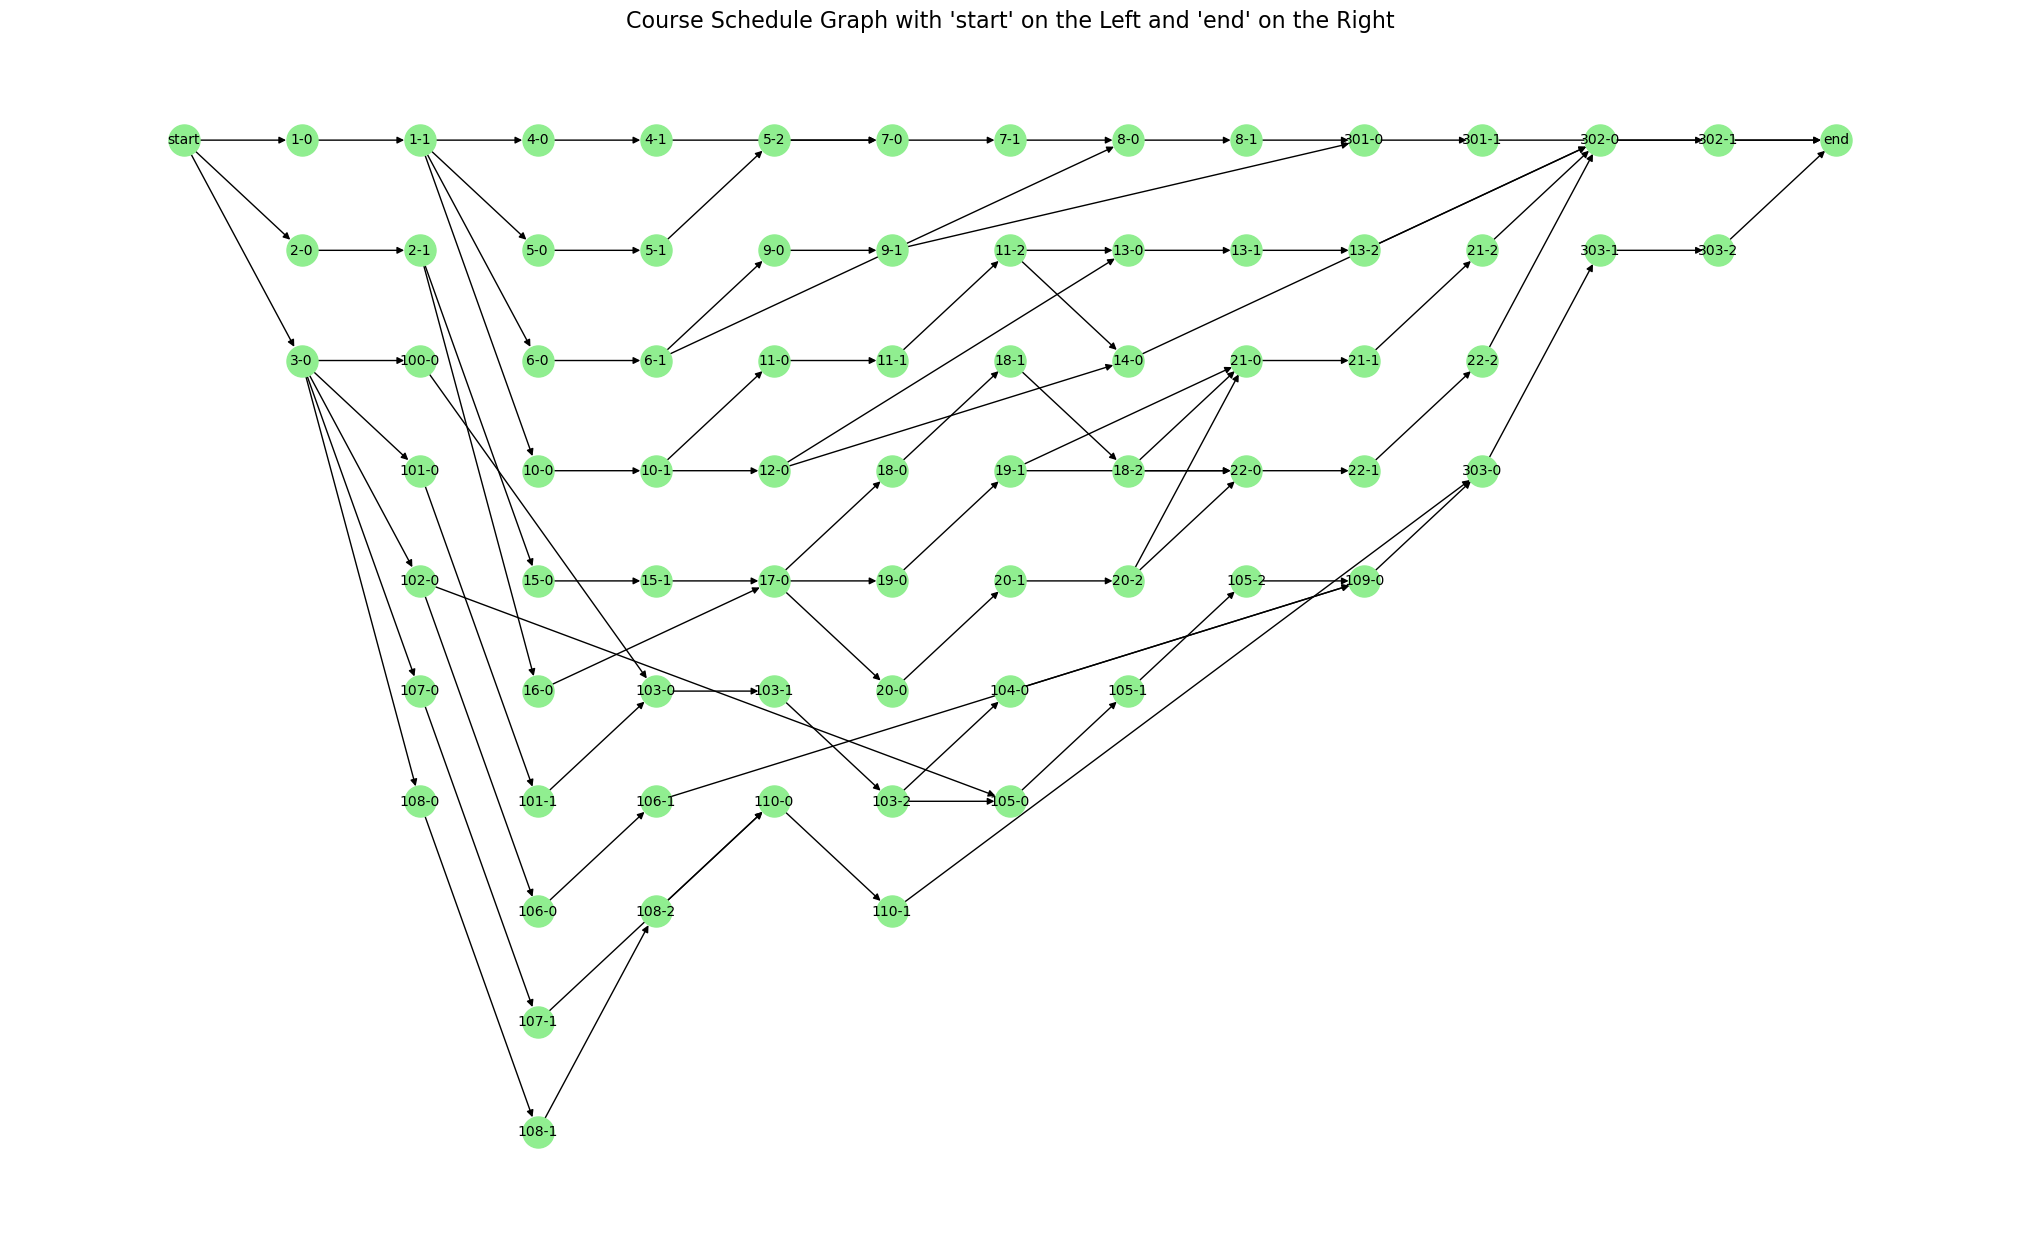

In [126]:
plotSchedule(pert.returnGraphSymbolic())

In [127]:
pert.returnGraphSymbolic()

{'start': ['1-0', '2-0', '3-0'],
 '1-0': ['1-1'],
 '1-1': ['4-0', '5-0', '6-0', '10-0'],
 '2-0': ['2-1'],
 '2-1': ['15-0', '16-0'],
 '3-0': ['100-0', '101-0', '102-0', '107-0', '108-0'],
 '4-0': ['4-1'],
 '4-1': ['7-0'],
 '5-0': ['5-1'],
 '5-1': ['5-2'],
 '5-2': ['7-0'],
 '6-0': ['6-1'],
 '6-1': ['8-0', '9-0'],
 '7-0': ['7-1'],
 '7-1': ['8-0'],
 '8-0': ['8-1'],
 '8-1': ['301-0'],
 '9-0': ['9-1'],
 '9-1': ['301-0'],
 '10-0': ['10-1'],
 '10-1': ['11-0', '12-0'],
 '11-0': ['11-1'],
 '11-1': ['11-2'],
 '11-2': ['13-0', '14-0'],
 '12-0': ['13-0', '14-0'],
 '13-0': ['13-1'],
 '13-1': ['13-2'],
 '13-2': ['302-0'],
 '14-0': ['302-0'],
 '15-0': ['15-1'],
 '15-1': ['17-0'],
 '16-0': ['17-0'],
 '17-0': ['18-0', '19-0', '20-0'],
 '18-0': ['18-1'],
 '18-1': ['18-2'],
 '18-2': ['21-0', '22-0'],
 '19-0': ['19-1'],
 '19-1': ['21-0', '22-0'],
 '20-0': ['20-1'],
 '20-1': ['20-2'],
 '20-2': ['21-0', '22-0'],
 '21-0': ['21-1'],
 '21-1': ['21-2'],
 '21-2': ['302-0'],
 '22-0': ['22-1'],
 '22-1': ['22-2'],
 